In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
df = pd.read_csv("../data/processed/cleaned_salary_data.csv")
print(df.shape)

df.head()
df.info()

(565, 9)
<class 'pandas.DataFrame'>
RangeIndex: 565 entries, 0 to 564
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           565 non-null    int64
 1   experience_level    565 non-null    str  
 2   employment_type     565 non-null    str  
 3   job_title           565 non-null    str  
 4   employee_residence  565 non-null    str  
 5   remote_ratio        565 non-null    int64
 6   company_location    565 non-null    str  
 7   company_size        565 non-null    str  
 8   salary_in_usd       565 non-null    int64
dtypes: int64(3), str(6)
memory usage: 39.9 KB


In [4]:
X = df.drop(columns=["salary_in_usd"])

y = df["salary_in_usd"]
numeric_columns = [
    "work_year",
    "remote_ratio"
]
categorical_columns = [
    "experience_level",
    "employment_type",
    "job_title",
    "employee_residence",
    "company_location",
    "company_size"
]

: Build Preprocessor

In [ ]:

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_columns
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ],
    # remainder="passthrough"
    remainder="drop"
)

    `Model Pipeline`

In [6]:
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)
print(model_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['work_year',
                                                   'remote_ratio']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['experience_level',
                                                   'employment_type',
                                                   'job_title',
                                                   'employee_residence',
                                                   'company_location',
                                                   'company_size'])])),
                ('model', LinearRegression())])


In [7]:
y = df["salary_in_usd"]
X = df.drop(columns=["salary_in_usd"])
print(X.shape)
print(y.shape)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,   random_state =42
)

(565, 8)
(565,)


In [9]:
model_pipeline.fit(X_train, y_train)
y_predict=model_pipeline.predict(X_test)
y_predict
print(f"Number of predictions: {len(y_predict)}")
print(f"Number of actual values: {len(y_test)}")

Number of predictions: 113
Number of actual values: 113


In [10]:
mae= mean_absolute_error(y_test, y_predict)
print(f"MAE: {mae}")
mse= mean_squared_error(y_test, y_predict)
print(f"MSE: {mse}")
rmse= np.sqrt(mse)
print(f"RMSE: {rmse}")
r2= r2_score(y_test, y_predict)
print(f"R2: {r2}")



MAE: 33032.490492735546
MSE: 3084566987.2072167
RMSE: 55538.87815942285
R2: 0.35789876230451667


In [11]:
metrics_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Value": [mae, mse, rmse, r2]
})

metrics_df

,Metric,Value
0,MAE,3.303249e+04
1,MSE,3.084567e+09
2,RMSE,5.553888e+04
3,R2 Score,3.578988e-01


In [13]:
predictions_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted":y_predict
})
predictions_df.head()
predictions_df["Error"] = predictions_df["Actual"] - predictions_df["Predicted"]

predictions_df.head(10)


,Actual,Predicted,Error
538,80000,121606.404536,-41606.404536
523,205300,157186.381859,48113.618141
234,110000,65779.483376,44220.516624
524,176000,154432.927016,21567.072984
486,64849,93608.192821,-28759.192821
318,132320,147375.906873,-15055.906873
247,96282,107085.112316,-10803.112316
496,68147,54671.685518,13475.314482
390,175000,149632.202498,25367.797502
222,56256,88488.652530,-32232.652530


Minimum Salary: -553.0518575238093
Maximum Salary: 450000


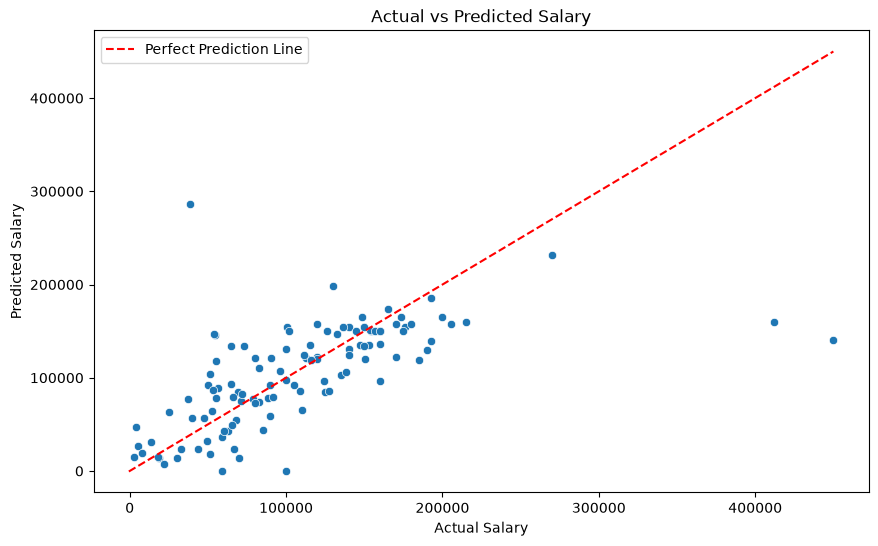

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=predictions_df["Actual"],
    y=predictions_df["Predicted"]
)
min_salary = min(predictions_df["Actual"].min(), predictions_df["Predicted"].min())
max_salary = max(predictions_df["Actual"].max(), predictions_df["Predicted"].max())
print(f"Minimum Salary: {min_salary}")
print(f"Maximum Salary: {max_salary}")

# plt.xlim(min_salary, max_salary)
# plt.ylim(min_salary, max_salary)
# plt.xlabel("Actual Salary")


plt.plot(
    [min_salary, max_salary],
    [min_salary, max_salary],
    color="red",
    linestyle="--",
    label="Perfect Prediction Line"
)
plt.title("Actual vs Predicted Salary")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.legend()
plt.show()


     Actual      Predicted         Error      Residual
538   80000  121606.404536 -41606.404536 -41606.404536
523  205300  157186.381859  48113.618141  48113.618141
234  110000   65779.483376  44220.516624  44220.516624
524  176000  154432.927016  21567.072984  21567.072984
486   64849   93608.192821 -28759.192821 -28759.192821
318  132320  147375.906873 -15055.906873 -15055.906873
247   96282  107085.112316 -10803.112316 -10803.112316
496   68147   54671.685518  13475.314482  13475.314482
390  175000  149632.202498  25367.797502  25367.797502
222   56256   88488.652530 -32232.652530 -32232.652530


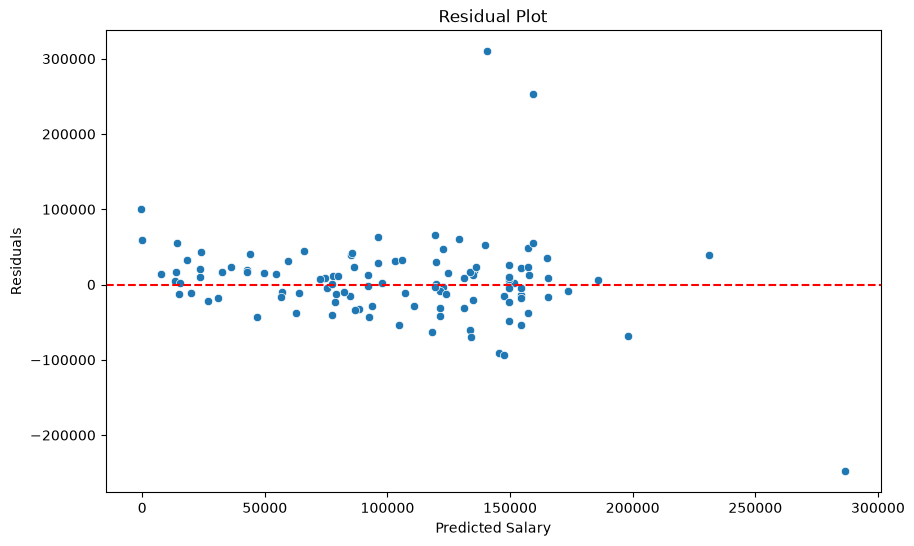

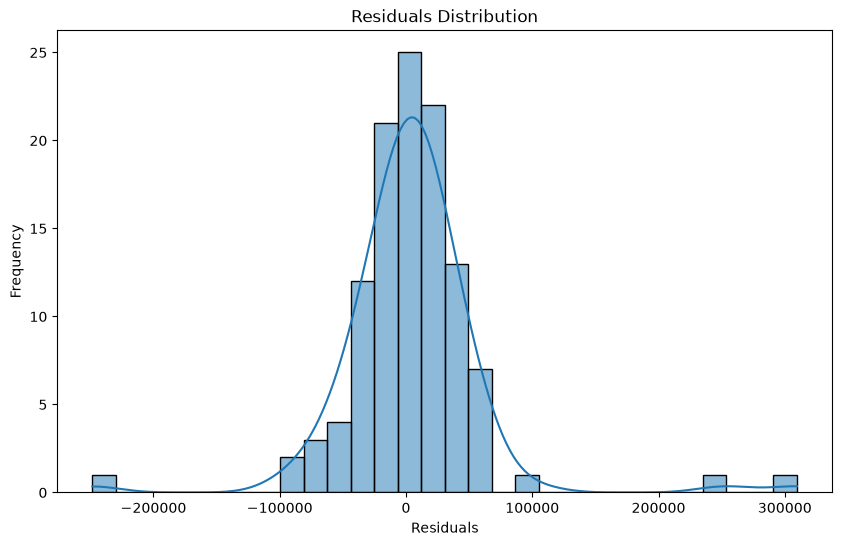

In [24]:
residuals = y_test.values - y_predict

predictions_df["Residual"] = residuals
print(predictions_df.head(10))
predictions_df.head(10)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=y_predict,
    y=residuals
)
plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.show()
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()


## Evaluation Summary

The baseline Linear Regression model was trained and evaluated successfully.

### Metrics

- MAE shows the average absolute salary prediction error.
- MSE penalizes larger errors more strongly.
- RMSE gives the prediction error in salary units.
- R² score shows how much salary variance is explained by the model.

### Observations

The model works end to end, but salary prediction is complex.

If the training R² is much higher than the test R², the model may be overfitting.

Possible reasons:

- many one-hot encoded job title and location categories
- rare categories
- salary outliers
- limited dataset size
- Linear Regression may be too simple for all salary patterns

### Next Improvements

Future improvements may include:

- grouping rare job titles
- handling outliers carefully
- using regularized regression such as Ridge or Lasso
- adding better features
- comparing sklearn Linear Regression with a from-scratch implementation